In [1]:
import yfinance as yf
msft = yf.Ticker("MPC")
aapl = yf.Ticker("PSX")
df_msft=msft.history(period="40y")
df_apple=aapl.history(period="40y")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LinearRegression
np.random.seed(67)

df_msft.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3764.000000,3764.000000,3764.000000,3764.000000,3.764000e+03,3764.000000,3764.000000
mean,67.178883,68.169168,66.228406,67.203884,5.535886e+06,0.007921,0.000531
std,55.591222,56.393140,54.870577,55.646080,3.083791e+06,0.070254,0.032599
min,8.812036,9.140845,8.664075,8.897532,4.241300e+05,0.000000,0.000000
25%,30.010339,30.566635,29.507382,29.997711,3.380300e+06,0.000000,0.000000
50%,42.908153,43.408143,42.602516,43.030880,5.060600e+06,0.000000,0.000000
75%,94.463030,95.934194,92.932770,93.822426,6.909875e+06,0.000000,0.000000
max,268.000000,272.459991,263.130005,267.209991,3.915380e+07,1.000000,2.000000


In [3]:
data_apple = df_apple["Close"]
data_microsoft = df_msft["Close"]
data_apple = data_apple[-3500:]
data_microsoft = data_microsoft[-3500:]
print(len(data_microsoft))

3500


In [4]:
# AI generated
def estimate_all_params(S1, S2):
    S1, S2 = np.array(S1), np.array(S2)

    # Step 1: estimate beta, keep the intercept
    model     = LinearRegression(fit_intercept=True).fit(S2.reshape(-1,1), S1)
    beta      = -model.coef_[0]
    intercept =  model.intercept_

    # Step 2: construct series, removing the regression intercept from eps
    eps = S1 + beta * S2 - intercept   # now mean-zero; c1 is purely the AR drift
    e   = np.diff(S2)

    # Step 3: fit AR(1)
    def fit_ar1(series):
        res = AutoReg(series, lags=1).fit()
        c, phi = res.params
        sigma  = np.sqrt(res.sigma2)
        return phi, c, sigma

    phi1, c1, sigma1 = fit_ar1(eps)
    phi2, c2, sigma2 = fit_ar1(e)

    return dict(beta=beta, intercept=intercept,
                phi1=phi1, c1=c1, sigma1=sigma1,
                phi2=phi2, c2=c2, sigma2=sigma2)

Window 0: c1=0.015722369159055515 c2=0.036717898640208045 phi1=0.972, phi2=-0.001, sigma1=0.4821, sigma2=0.4903, beta=-1.410
Window 1: c1=0.007979982004446655 c2=0.006494291539032353 phi1=0.972, phi2=0.122, sigma1=0.7043, sigma2=0.6449, beta=-0.311
Window 2: c1=-0.0023561412318771867 c2=0.008730579913014437 phi1=0.967, phi2=-0.062, sigma1=0.6763, sigma2=0.7483, beta=-0.271
Window 3: c1=0.004268916037771895 c2=0.035985482373856674 phi1=0.976, phi2=0.028, sigma1=0.7345, sigma2=0.9143, beta=-1.134
Window 4: c1=0.014494652725797526 c2=-0.03984244343877735 phi1=0.987, phi2=0.021, sigma1=1.0000, sigma2=1.2172, beta=-1.023
Window 5: c1=-0.020404066518799096 c2=0.0879056063185508 phi1=0.980, phi2=-0.068, sigma1=0.9445, sigma2=1.0207, beta=-0.707
Window 6: c1=-0.008965234185768996 c2=0.18497154525499104 phi1=0.952, phi2=-0.037, sigma1=1.1586, sigma2=2.1824, beta=-0.477
Window 7: c1=0.02519707478163008 c2=0.022181730790084547 phi1=0.968, phi2=0.017, sigma1=1.2581, sigma2=2.9100, beta=-0.682


C:\Users\lpset\AppData\Local\Temp\ipykernel_18472\83620396.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_gen = [s1[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_18472\83620396.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s2_gen = [s2[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_18472\83620396.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  et=s2[1]-s2[0]


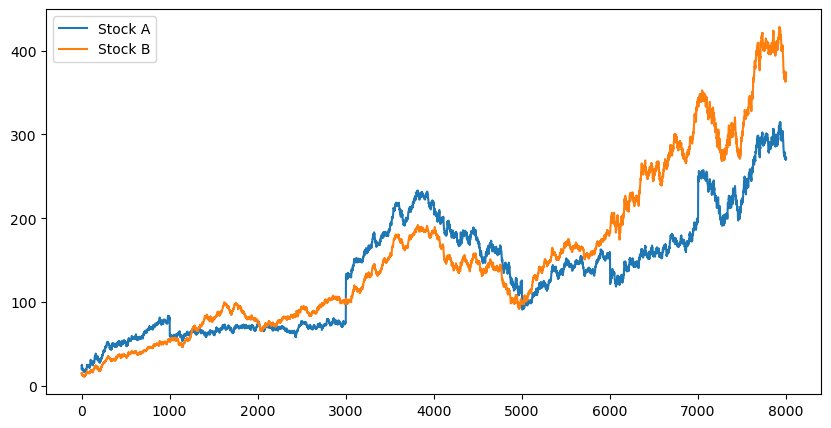

In [5]:
s1 = data_apple
s2 = data_microsoft

window_size = 400
points_per_window = 1000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
for i in range(len(s1)//window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    for j in range(points_per_window):
        epst = params["c1"]+params["sigma1"]*np.random.normal()+params["phi1"]*epst
        et = params["c2"]+params["sigma2"]*np.random.normal()+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

for i in range(len(s1) // window_size):
    params = estimate_all_params(s1[i*window_size:(i+1)*window_size], s2[i*window_size:(i+1)*window_size])
    print(f"Window {i}: c1={params["c1"]} c2={params["c2"]} phi1={params['phi1']:.3f}, phi2={params['phi2']:.3f}, "
          f"sigma1={params['sigma1']:.4f}, sigma2={params['sigma2']:.4f}, "
          f"beta={params['beta']:.3f}")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen, label = "Stock A")
ax.plot(s2_gen, label = "Stock B")
# ax.set_yscale('log')
ax.legend()
plt.show()

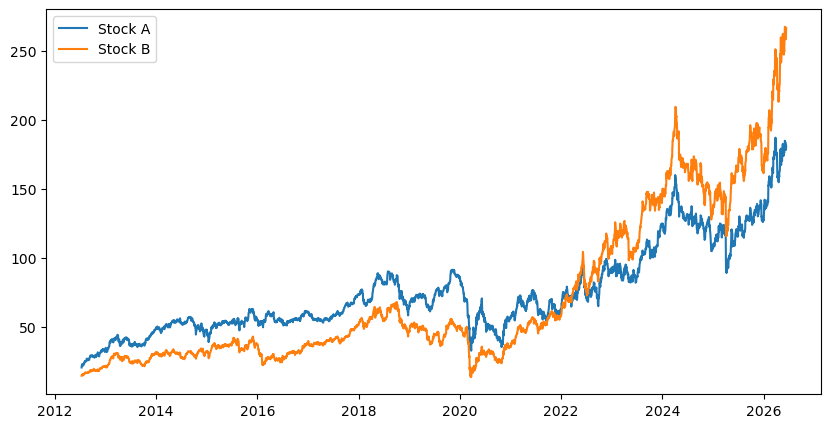

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_apple, label="Stock A")
ax.plot(data_microsoft, label="Stock B")
# ax.set_yscale('log')
ax.legend()

In [7]:
s1 = data_apple
s2 = data_microsoft

window_size = len(s1)-1
points_per_window = 400000
s1_gen = [s1[0]]
s2_gen = [s2[0]]
et=s2[1]-s2[0]
epst=0
betas = []
for i in range(len(s1)-window_size):
    params = estimate_all_params(s1[i:i+window_size], s2[i:i+window_size])
    betas.append(params["beta"])
    for j in range(points_per_window):
        epst = params["c1"]/points_per_window+params["sigma1"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi1"]*epst
        et = params["c2"]/points_per_window+params["sigma2"]*np.random.normal()*np.sqrt(points_per_window)/points_per_window+params["phi2"]*et
        s2_gen.append(et+s2_gen[-1])
        s1_gen.append(epst-params["beta"]*s2_gen[-1]+params["intercept"])

C:\Users\lpset\AppData\Local\Temp\ipykernel_18472\1214093683.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s1_gen = [s1[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_18472\1214093683.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s2_gen = [s2[0]]
C:\Users\lpset\AppData\Local\Temp\ipykernel_18472\1214093683.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  et=s2[1]-s2[0]


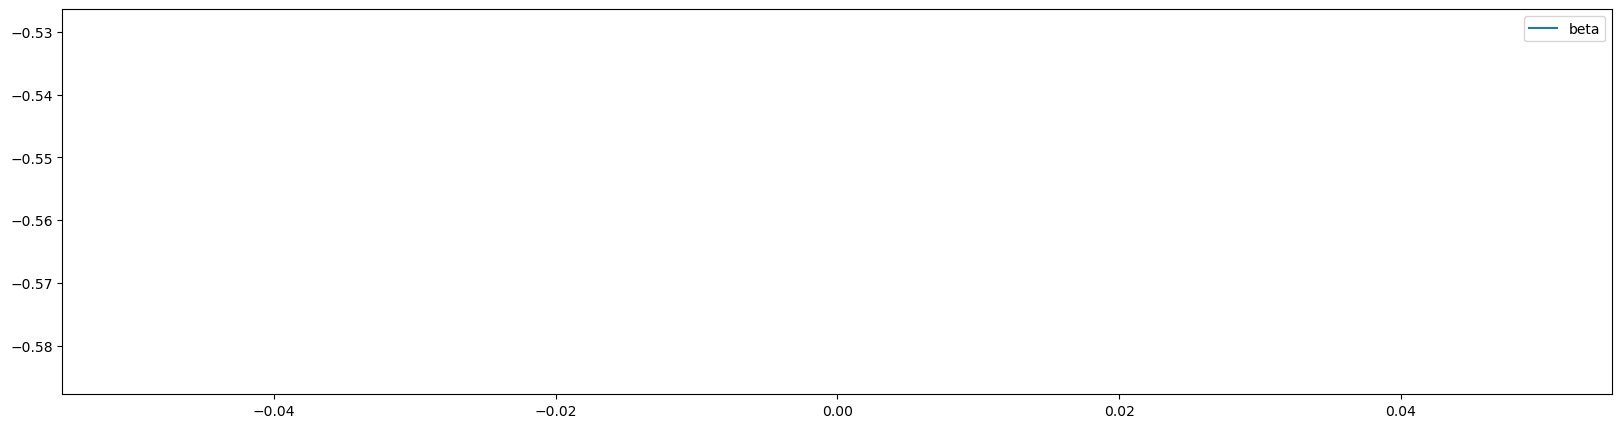

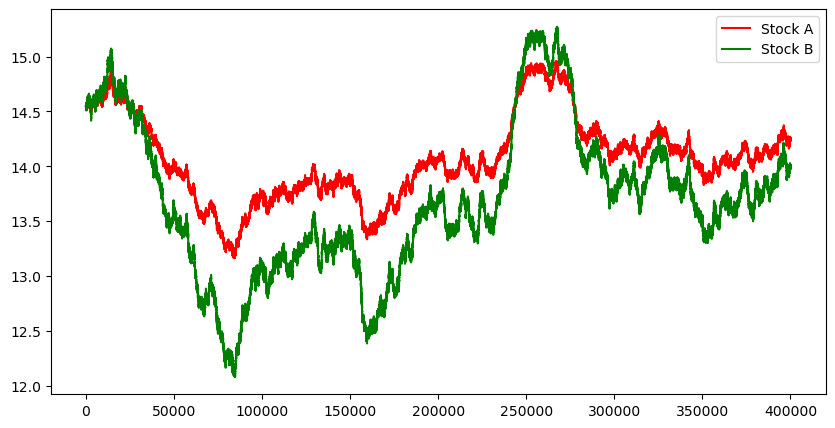

In [8]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(betas, label = "beta")
ax.legend()
plt.show()
s1_gen = np.array(s1_gen)
s2_gen = np.array(s2_gen)
s1_gen -= (s1_gen[2]-s2_gen[2])
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s1_gen[1:], label="Stock A", color='red')
ax.plot(s2_gen[1:], label="Stock B", color='green')
# ax.set_yscale('log')
ax.legend()

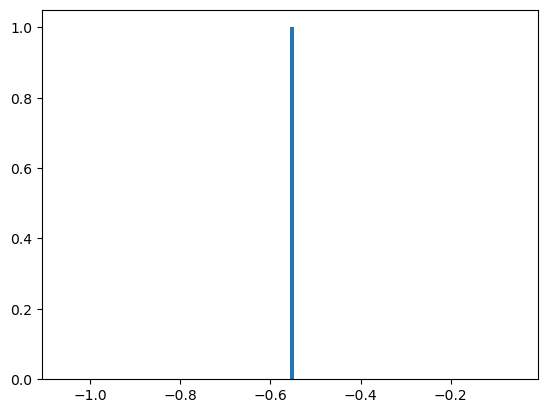

In [9]:
plt.hist(betas, bins=100)
plt.show()

In [10]:
import pandas as pd

# Sample Data
data = {"s1":s1_gen[1:], "s2":s2_gen[1:]}
df = pd.DataFrame(data)
# Output to CSV
df.to_csv('data_one_regime.csv', index=False)

Generating 400,000 data points...
Saved → cointegrated_ko_pep.parquet  |  shape: (400000, 2)
                 KO           PEP
count  4.000000e+05  4.000000e+05
mean   3.264354e+36  3.700829e+39
std    2.331591e+37  2.750557e+40
min    1.188200e+02  1.070089e+02
25%    1.821372e+11  9.597014e+11
50%    1.089289e+21  4.042742e+22
75%    8.196094e+27  1.207595e+30
max    3.463289e+38  3.966328e+41


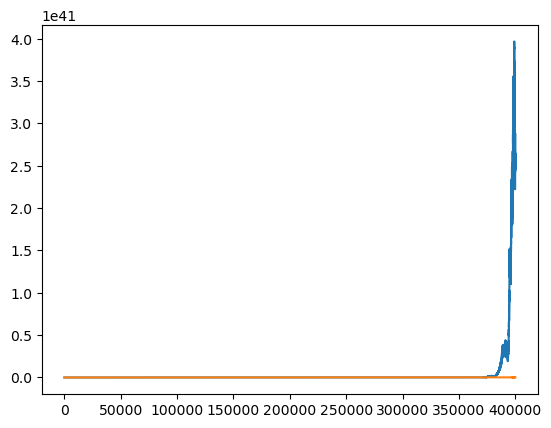

In [11]:
"""
Synthetic cointegrated stock pair generator.
Parameters calibrated to Coca-Cola (KO) / PepsiCo (PEP) daily data.

Model:
  log(KO_t) = beta * log(PEP_t) + Z_t + alpha
  Z_t follows an Ornstein-Uhlenbeck process:
    dZ = -kappa * Z * dt + sigma_z * dW_z

  PEP follows GBM:
    dS = mu * S * dt + sigma * S * dW
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── KO/PEP calibrated parameters ────────────────────────────────────────────
SEED        = 42
N           = 400_000          # data points

# PEP GBM (daily)
MU_PEP      = 0.0003           # daily drift
SIGMA_PEP   = 0.0105           # daily vol
S0_PEP      = 180.0            # starting price

# Cointegration
BETA        = 0.92             # log-price hedge ratio KO ~ beta * PEP
ALPHA       = 0.55             # log-price intercept  (ln(60) - 0.92*ln(180))
S0_KO       = 60.0             # starting price

# Spread OU process (on log-price residual)
KAPPA       = 0.04             # mean-reversion speed (daily)
SIGMA_Z     = 0.008            # OU noise
RHO         = 0.65             # correlation between PEP and spread shocks


def generate(n=N, seed=SEED):
    rng = np.random.default_rng(seed)

    # Correlated Brownian increments
    cov = np.array([[1.0, RHO], [RHO, 1.0]])
    L   = np.linalg.cholesky(cov)
    W   = rng.standard_normal((n, 2)) @ L.T   # shape (n, 2)

    dt = 1.0   # daily step

    # ── PEP log-price via Euler-Maruyama ────────────────────────────────────
    log_pep = np.empty(n + 1)
    log_pep[0] = np.log(S0_PEP)
    drift_pep  = (MU_PEP - 0.5 * SIGMA_PEP**2) * dt
    for i in range(n):
        log_pep[i + 1] = log_pep[i] + drift_pep + SIGMA_PEP * W[i, 0]

    # ── Spread Z (OU) ────────────────────────────────────────────────────────
    z = np.empty(n + 1)
    z[0] = 0.0
    for i in range(n):
        z[i + 1] = z[i] - KAPPA * z[i] * dt + SIGMA_Z * W[i, 1]

    # ── KO log-price from cointegration relationship ─────────────────────────
    log_ko = BETA * log_pep + ALPHA + z

    # Slice to n points (drop initial condition)
    pep = np.exp(log_pep[1:])
    ko  = np.exp(log_ko[1:])
    plt.plot(pep)
    plt.plot(ko)

    return pd.DataFrame({"KO": ko, "PEP": pep})


if __name__ == "__main__":
    print(f"Generating {N:,} data points...")
    df = generate()

    out = "cointegrated_ko_pep.parquet"
    df.to_parquet(out, index=False)
    print(f"Saved → {out}  |  shape: {df.shape}")
    print(df.describe().round(4))